# Cross-memory comparison — the interesting results

We ran the observability flow-grid matrix at **memory 1, 2, 3, 4** (each in its own
notebook). This notebook does the *same* finding-by-finding reading we did at
memory-1, but now tracks **how each pattern changes as the agents remember more
rounds** — the comparison *across* the notebooks.

Recap of the method: each grid is six observability regimes; each panel is the CRLD
deterministic learning flow (arrows) with two trajectories (purple), drawn in the
"everyone cooperated in every remembered round" state. (0,0) = mutual defection,
(1,1) = mutual cooperation. All agents are homogeneous, so we plot the agent-0 vs
agent-1 pair.

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib import image as mpimg
plt.rcParams.update({"figure.dpi": 130})
RESULTS = os.path.join(os.getcwd(), "results")
def show(fname, title, figsize=(12.5, 7.7)):
    p = os.path.join(RESULTS, fname)
    if not os.path.exists(p):
        print("(missing:", fname, ")"); return
    fig, ax = plt.subplots(figsize=figsize); ax.imshow(mpimg.imread(p)); ax.axis("off")
    ax.set_title(title, fontsize=11, loc="left", color="#114"); plt.show()


## C1. Longer memory grows a *cooperative basin* in the IPD (actor-critic)  ⭐

This is the headline cross-memory result.

- **memory-1:** the deterministic actor-critic flow drains to **mutual defection
  (0,0)** from essentially everywhere — no cooperative attractor.
- **memory-2, 3, 4:** a **cooperative basin appears** — under full observability a
  trajectory now climbs to **mutual cooperation (1,1)**, and the self-aware /
  conditional-tracking panels carry policies up the diagonal toward cooperation.

**Why:** with more remembered rounds the agents can represent memory-*k*
tit-for-tat / win-stay–lose-shift. Those reciprocal strategies make cooperation a
*deterministic* attractor, not merely a state the intrinsic fluctuations can stumble
into (cf. the memory-1 "fluctuations promote cooperation" story). So memory does for
the deterministic flow what finite-batch noise did at memory-1: it opens the door to
cooperation — but here it is visible in the arrows themselves.

Watch the **full-observability** panel (top-left) go from "all arrows into (0,0)" at
memory-1 to "a trajectory reaching (1,1)" at memory-2+.

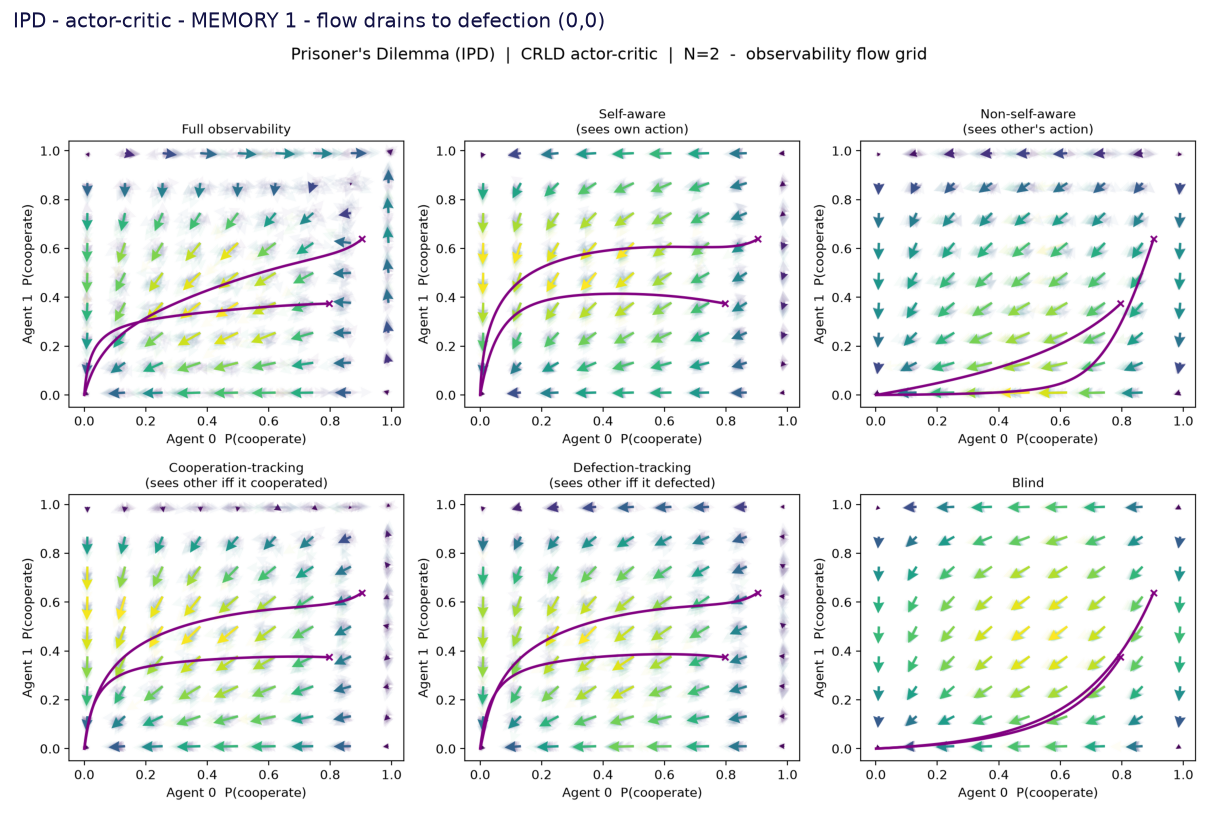

In [2]:
show('obsgrid_ipd_ac_N2.png', "IPD - actor-critic - MEMORY 1 - flow drains to defection (0,0)")

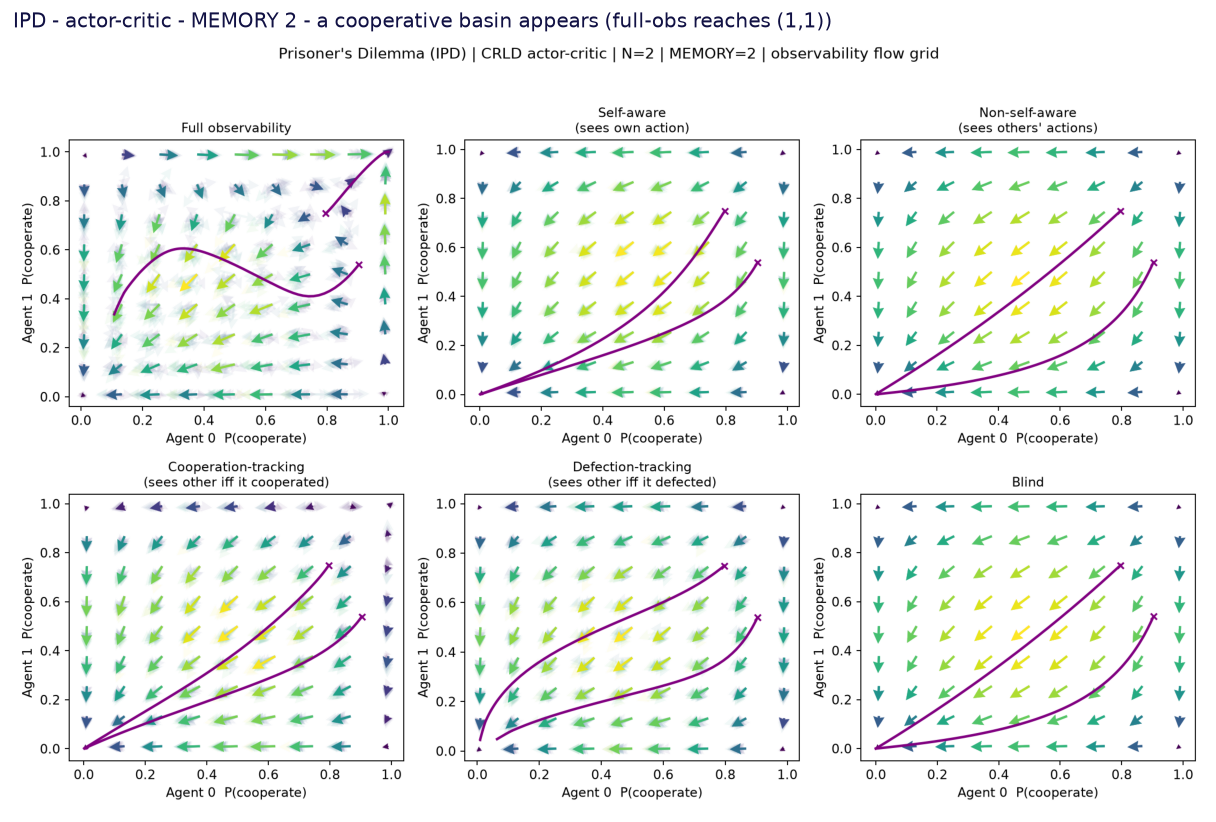

In [3]:
show('memgrid_m2_ipd_ac_N2.png', "IPD - actor-critic - MEMORY 2 - a cooperative basin appears (full-obs reaches (1,1))")

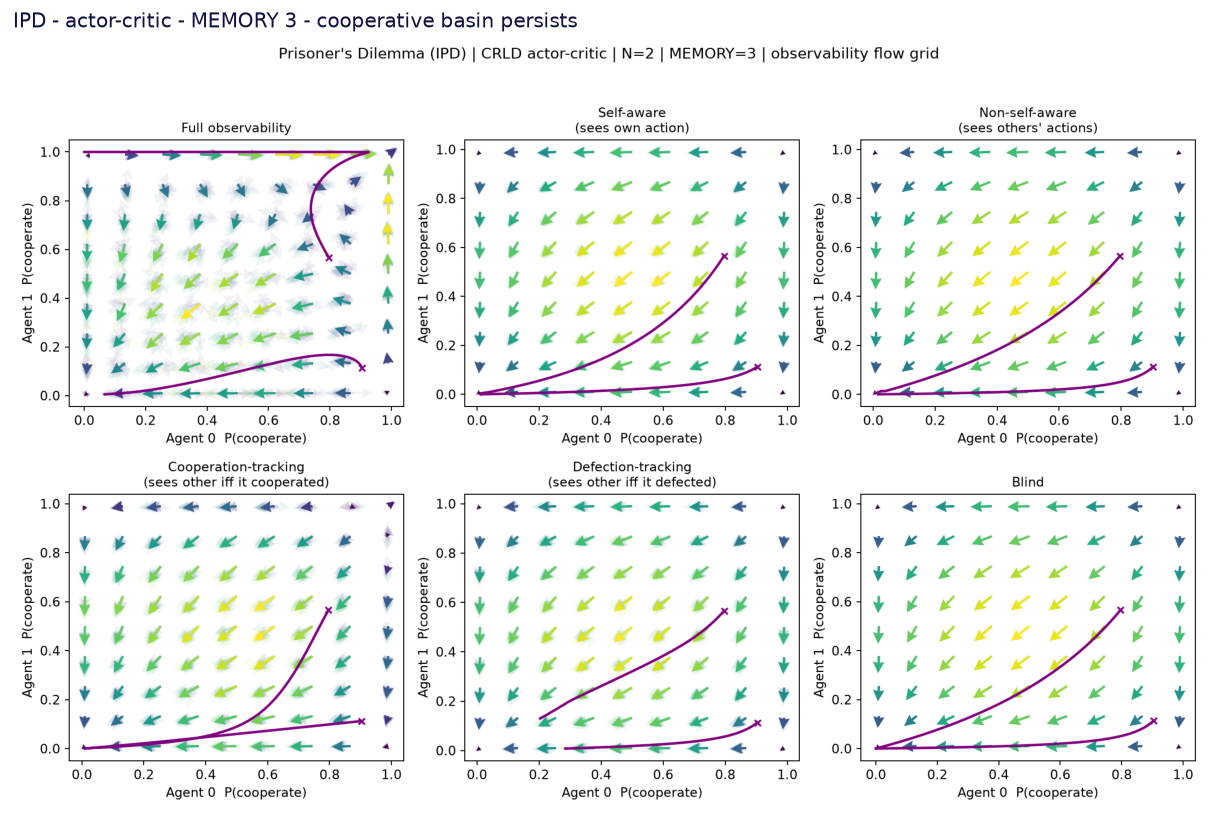

In [4]:
show('memgrid_m3_ipd_ac_N2.png', "IPD - actor-critic - MEMORY 3 - cooperative basin persists")

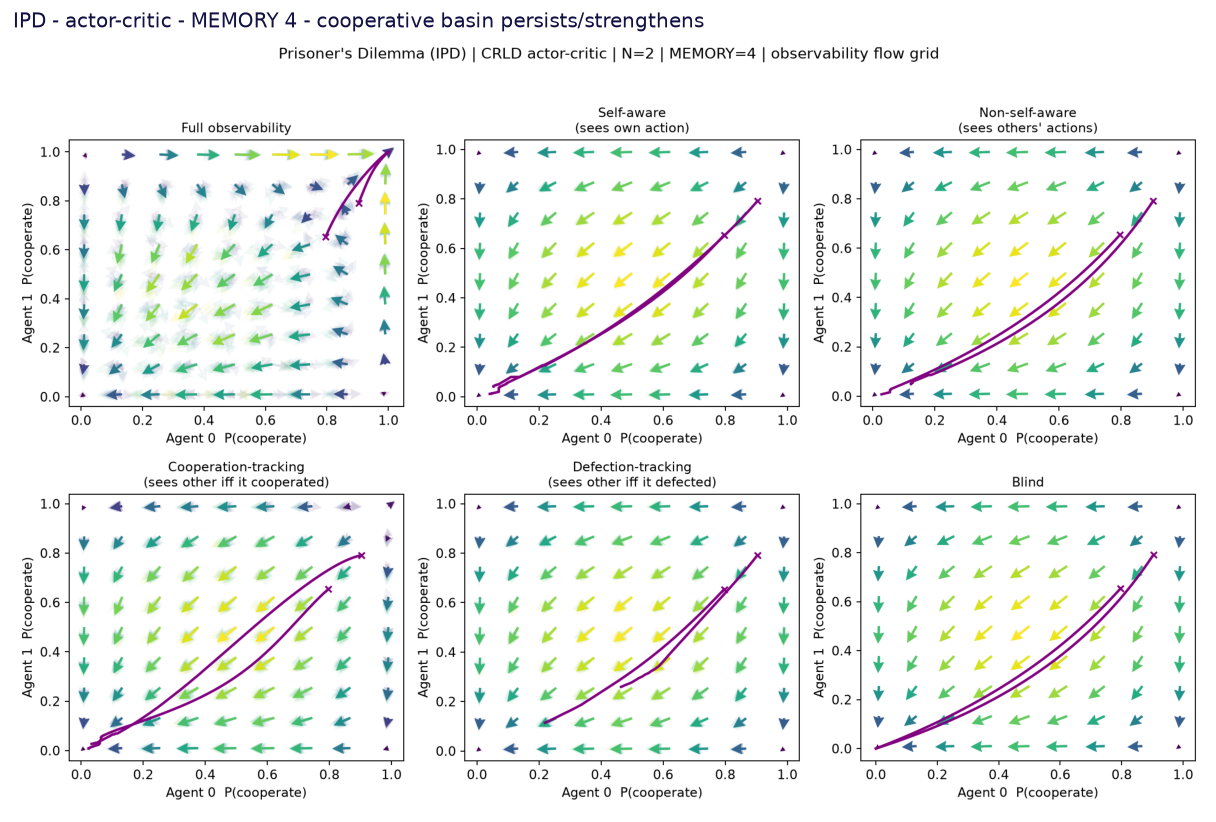

In [5]:
show('memgrid_m4_ipd_ac_N2.png', "IPD - actor-critic - MEMORY 4 - cooperative basin persists/strengthens")

## C2. The self-awareness advantage is **memory-invariant**

At *every* memory level the **self-aware** panel (sees own action) sustains more
cooperation than the **non-self-aware** panel (sees only the opponent). The reason is
unchanged by memory: reciprocal play is conditioned on *your own* last move, so an
agent that cannot see what it did cannot execute tit-for-tat / WSLS — at any history
length. Memory raises the ceiling (C1) but does not change *which* observation
matters.

Compare the top-middle (self-aware) vs top-right (non-self-aware) panels below; the
self-aware trajectories climb higher at both memory levels.

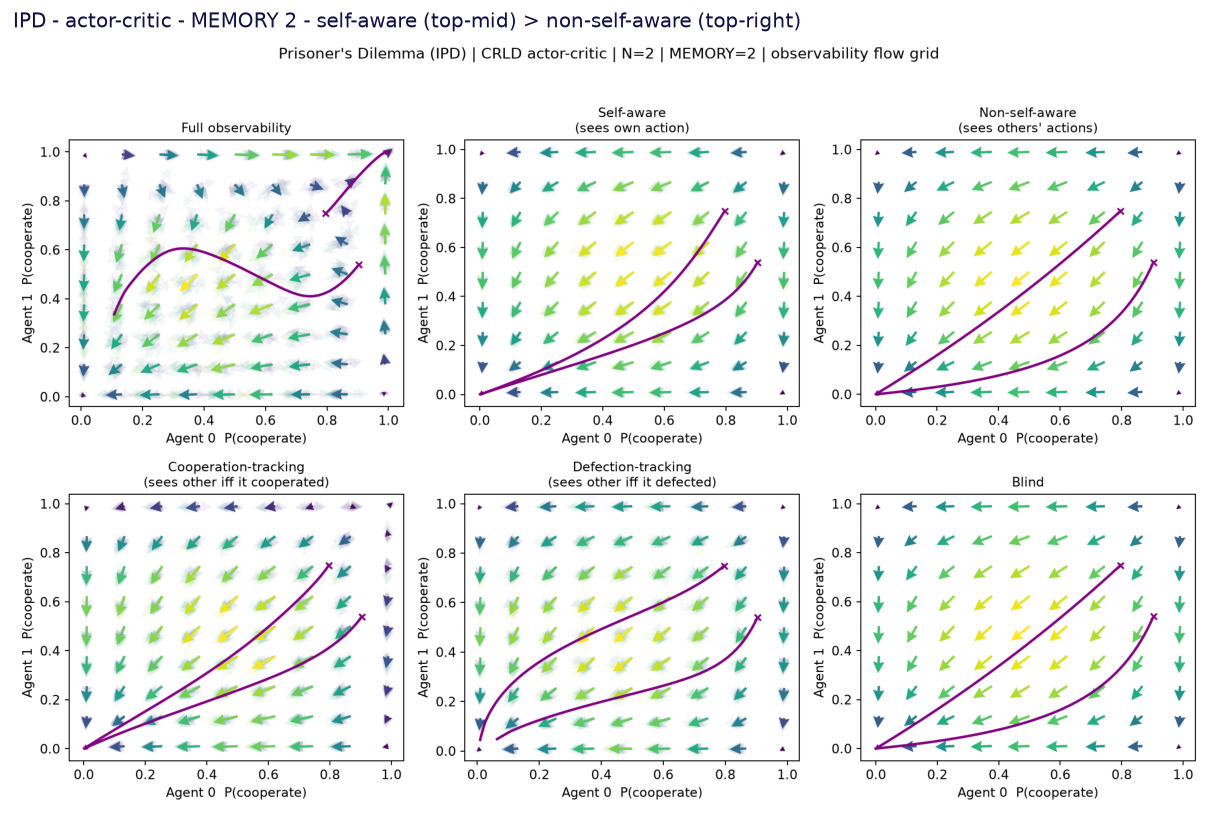

In [6]:
show('memgrid_m2_ipd_ac_N2.png', "IPD - actor-critic - MEMORY 2 - self-aware (top-mid) > non-self-aware (top-right)")

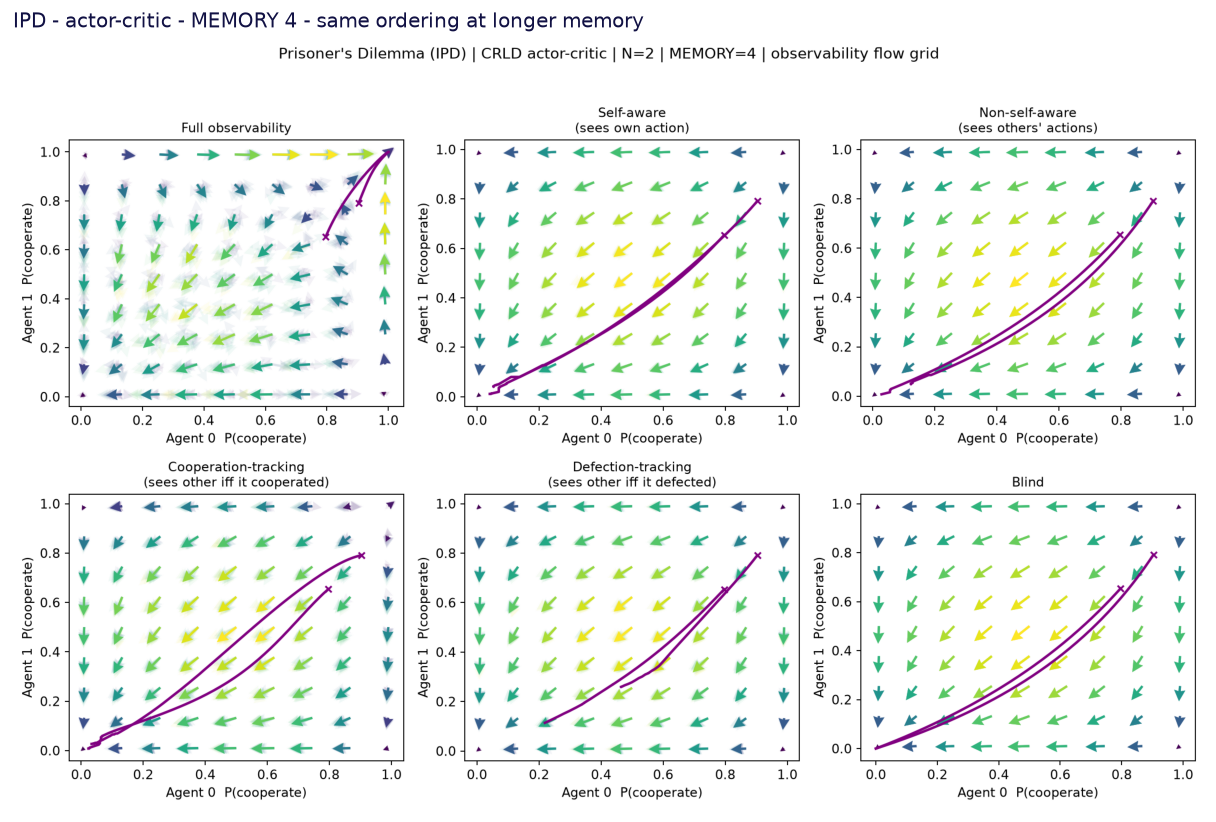

In [7]:
show('memgrid_m4_ipd_ac_N2.png', "IPD - actor-critic - MEMORY 4 - same ordering at longer memory")

## C3. Chicken's *algorithm-dependent equilibrium selection* is memory-invariant

The most distinctive memory-1 result — that in Snowdrift/Chicken **actor-critic
selects the pure anti-coordination corners** while **SARSA selects the symmetric
mixed point (0.5, 0.5)** — survives unchanged at higher memory. SARSA still
converges cleanly to (0.5, 0.5) in all six observability regimes; actor-critic still
splits toward the off-diagonal. The equilibrium an algorithm prefers is a property
of the *learning rule*, not of how much history it keeps.

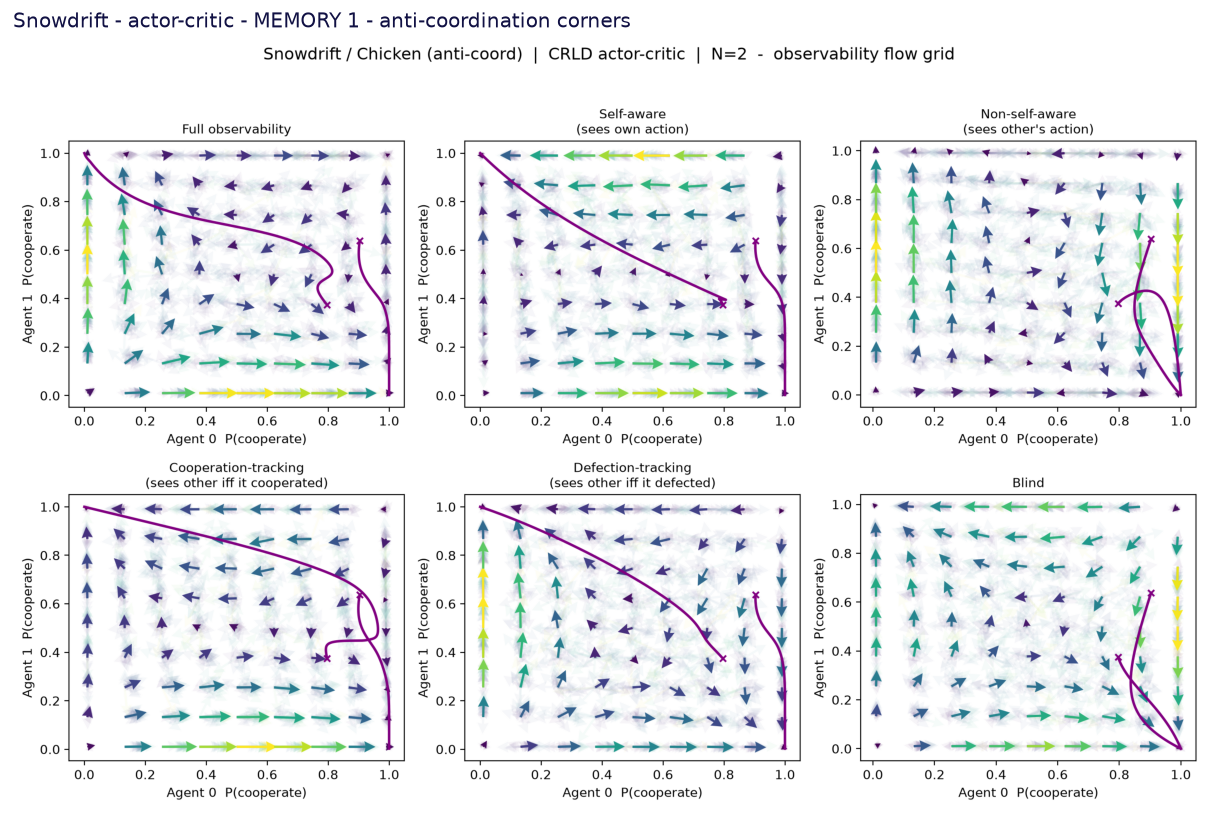

In [8]:
show('obsgrid_snowdrift_ac_N2.png', "Snowdrift - actor-critic - MEMORY 1 - anti-coordination corners")

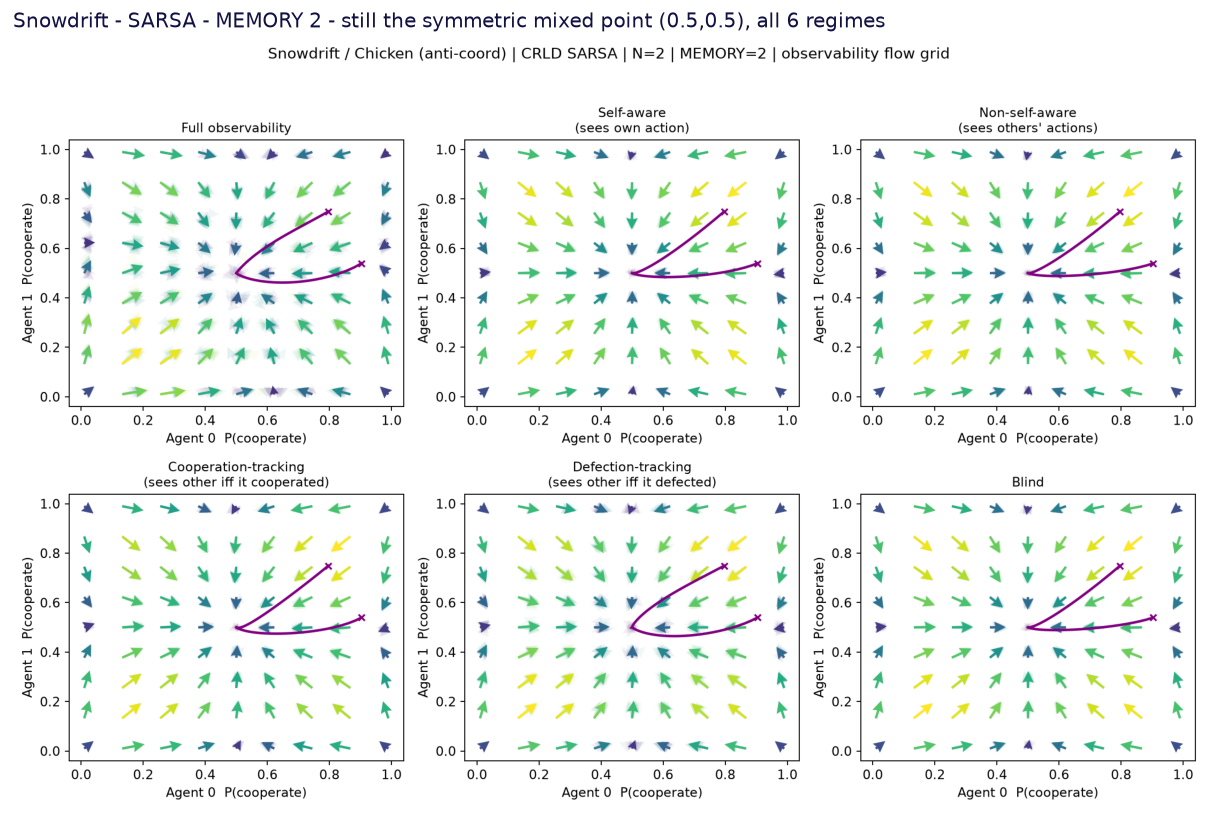

In [9]:
show('memgrid_m2_snowdrift_sarsa_N2.png', "Snowdrift - SARSA - MEMORY 2 - still the symmetric mixed point (0.5,0.5), all 6 regimes")

## C4. Value-based starts cooperative; policy-gradient *catches up* with memory

At **memory-1** the algorithms disagree sharply: SARSA (value-based) already sustains
partial cooperation in the IPD while actor-critic (policy gradient) defects. As memory
grows, actor-critic develops its *own* cooperative basin (C1), so the **gap between
the two rules narrows** — by memory-3/4 both can reach cooperation in the IPD, where
at memory-1 only the value-based learner did. Memory is thus a partial substitute for
the value-bootstrapping that made SARSA cooperative in the first place.

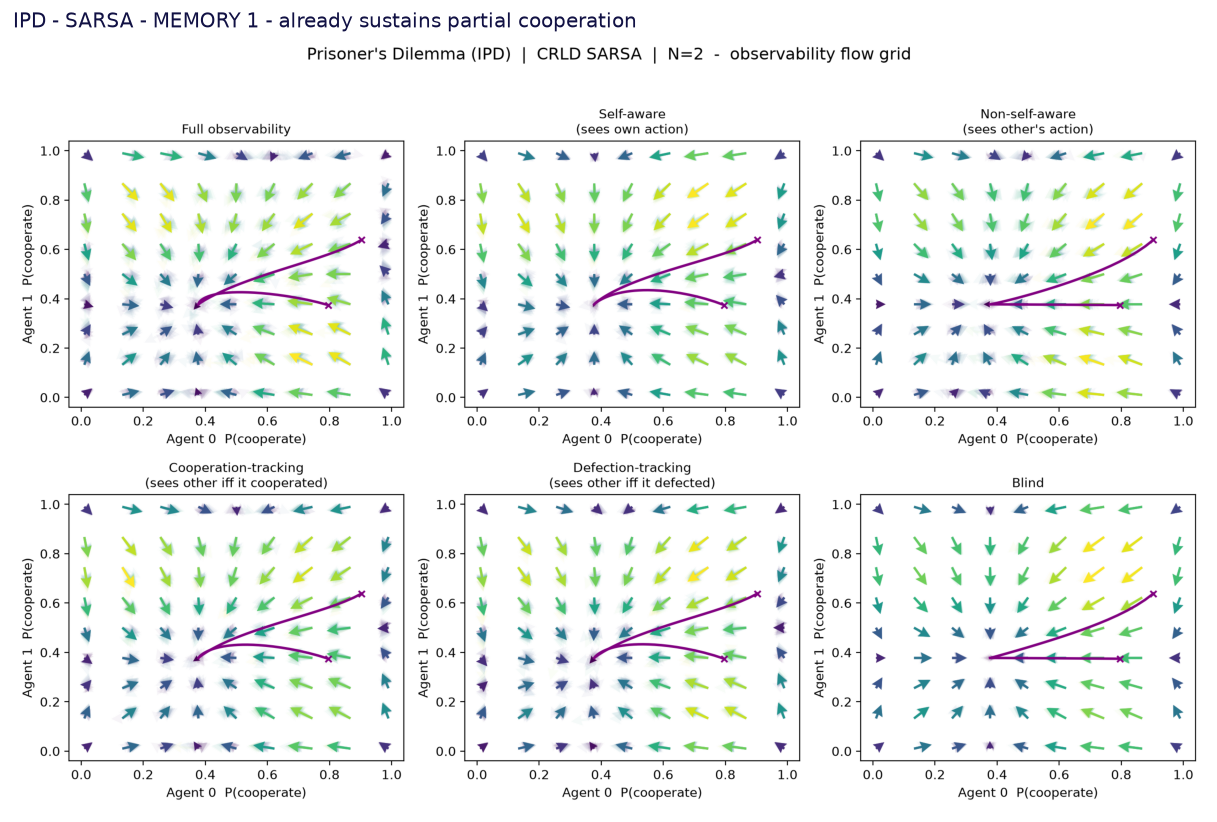

In [10]:
show('obsgrid_ipd_sarsa_N2.png', "IPD - SARSA - MEMORY 1 - already sustains partial cooperation")

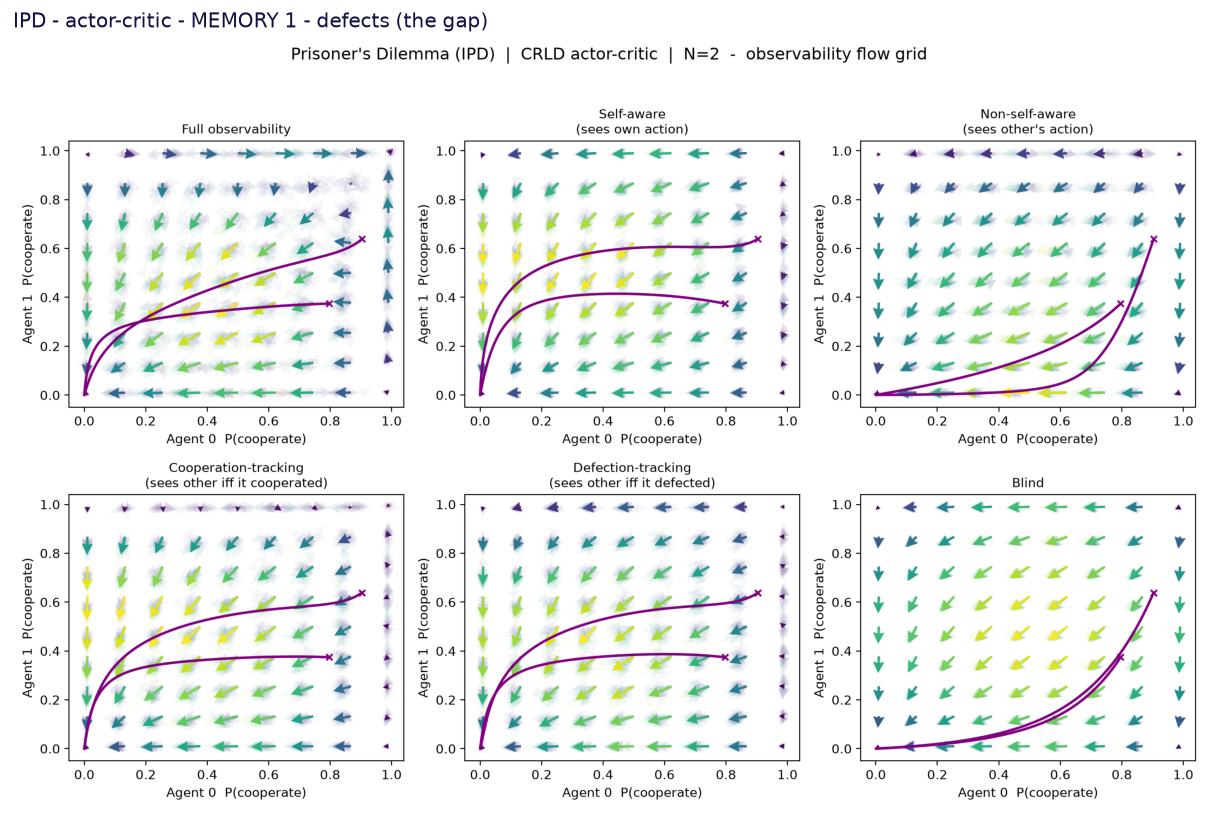

In [11]:
show('obsgrid_ipd_ac_N2.png', "IPD - actor-critic - MEMORY 1 - defects (the gap)")

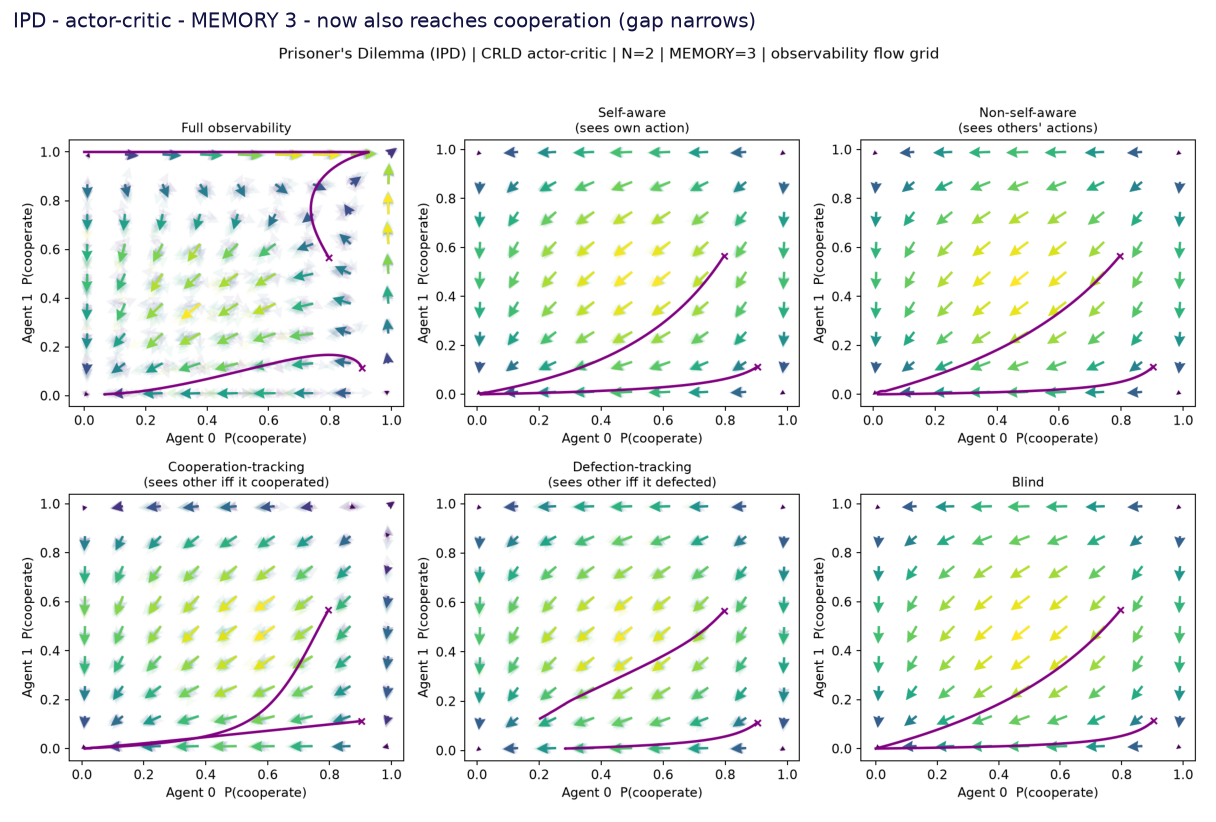

In [12]:
show('memgrid_m3_ipd_ac_N2.png', "IPD - actor-critic - MEMORY 3 - now also reaches cooperation (gap narrows)")

## Cross-memory summary

| finding | memory-1 | memory-2 → 4 |
|---|---|---|
| **C1** IPD actor-critic attractor | mutual defection (0,0) | cooperative basin appears — full-obs reaches (1,1) ⭐ |
| **C2** self- vs non-self-awareness | self-aware wins | **unchanged** — self-aware wins at every memory |
| **C3** Chicken equilibrium selection | AC → corners, SARSA → (0.5,0.5) | **unchanged** — memory-invariant |
| **C4** AC vs SARSA cooperation gap | large (SARSA cooperates, AC defects) | **narrows** — AC catches up via richer reciprocity |

**One-sentence takeaway.** More memory mostly acts like the intrinsic fluctuations of
the memory-1 story — it *enlarges the cooperative basin* (C1, C4) — while leaving the
*structural* facts (who-needs-to-see-what in C2, which-equilibrium-each-rule-picks in
C3) untouched.

### Caveats
- **Projection.** At memory-4 the policy is a 256-state object shown on 2 axes
  (averaging over the rest), so the higher-memory flow fields are noisier — read them
  as indicative of the basin, not exact.
- **Arena.** The N-player arena is capped at **N=2 for memory ≥ 3** — arena N≥3 has
  $(2^N)^M$ states (e.g. memory-4 N=3 = 4,096 states) that OOM / do not finish. The
  per-memory notebooks carry the exact size table.
- **Memory-10** flow plots are impossible (≈10⁶ states); the memory-10 *cooperation*
  result lives in the deep-RL memory sweep instead.